In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [4]:
df = pd.read_csv(r"C:\AIml_intern\data\insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [6]:
df.shape

(27, 2)

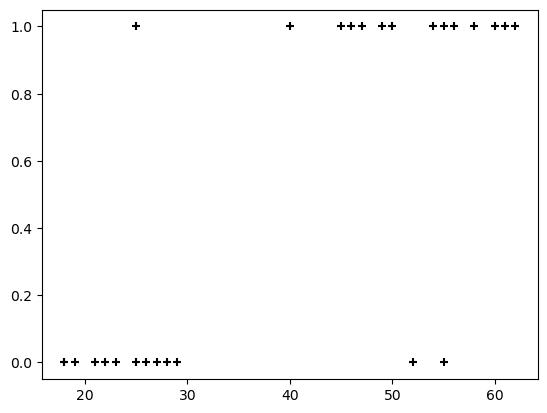

In [9]:
plt.scatter(df.age,df.bought_insurance,color = 'black',marker='+')

In [11]:
x = df[['age']]
y = df['bought_insurance']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=10)

In [14]:
x_test

,age
7,60
5,56
18,19
21,26
11,28
1,25


In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
model.coef_

array([[0.112778]])

In [18]:
model.intercept_

array([-4.20278276])

In [19]:
y_predict = model.predict(x_test)

In [20]:
y_predict

array([1, 1, 0, 0, 0, 0])

In [24]:
df['probs'] = model.predict_proba(df[['age']])[:,1]

In [25]:
df

,age,bought_insurance,probs
0,22,0,0.151657
1,25,0,0.200474
2,47,1,0.749845
3,52,0,0.840463
4,46,1,0.728100
5,56,1,0.892140
6,55,0,0.880798
7,60,1,0.928502
8,62,1,0.942103
9,61,1,0.935636


Text(0, 0.5, 'probs')

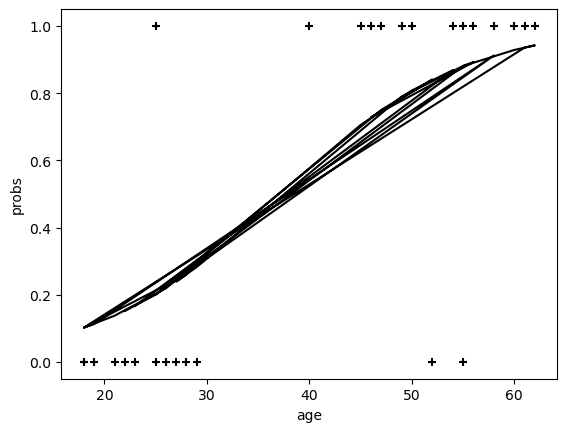

In [30]:
plt.scatter(df.age,df.bought_insurance,color = 'black',marker='+')
plt.plot(df['age'],df['probs'],color='black')
plt.xlabel('age')
plt.ylabel('probs')
#plt('')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\AIml_intern\data\HR.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [6]:
df.groupby('left').mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


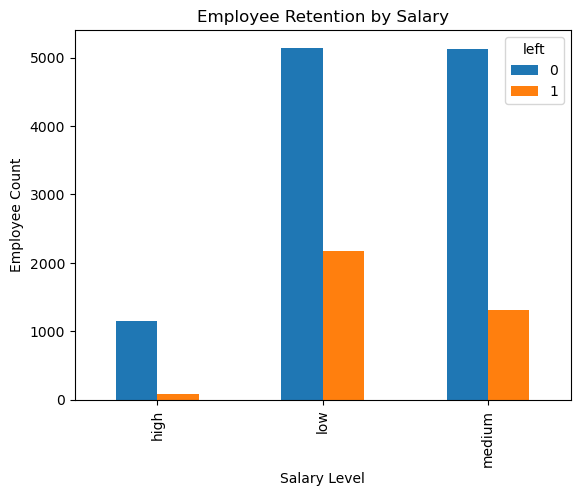

In [7]:
pd.crosstab(df.salary, df.left).plot(kind='bar')

plt.title("Employee Retention by Salary")
plt.xlabel("Salary Level")
plt.ylabel("Employee Count")
plt.show()

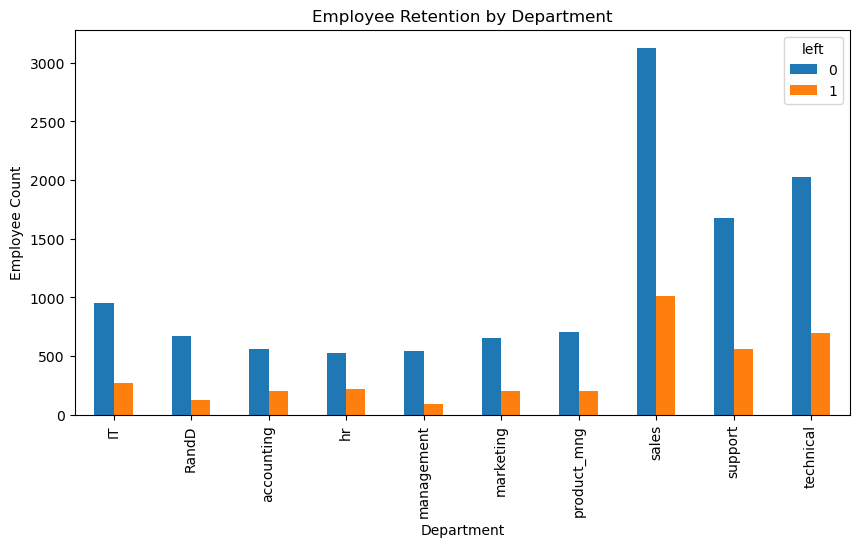

In [10]:
pd.crosstab(df.Department, df.left).plot(kind='bar', figsize=(10,5))

plt.title("Employee Retention by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [12]:
subdf = df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]

In [13]:
salary_dummies = pd.get_dummies(subdf.salary)
df_with_dummies = pd.concat([subdf, salary_dummies], axis='columns')
df_with_dummies.drop('salary', axis='columns', inplace=True)

In [14]:
X = df_with_dummies
y = df.left

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [16]:
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
model.score(X_test,y_test)

0.7673333333333333

In [18]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [19]:
iris = load_iris()

In [20]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [21]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [22]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [23]:
X = df.drop('target', axis=1)
y = df.target

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [25]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
model.score(X_test, y_test)

0.9333333333333333

In [30]:
sample = pd.DataFrame(
    [[5.1,3.5,1.4,0.2]],
    columns=iris.feature_names
)

model.predict(sample)

array([0])

In [29]:
sample = pd.DataFrame(
    [[6.2, 3.4, 5.4, 2.3]],
    columns=iris.feature_names
)

model.predict(sample)

array([2])

In [33]:
#iris.target_names[model.predict([[5.1,3.5,1.4,0.2]])]

sample = pd.DataFrame(
    [[5.1,3.5,1.4,0.2]],
    columns=iris.feature_names
)

iris.target_names[model.predict(sample)]

array(['setosa'], dtype='<U10')